
--- TASK 1: Equality Constraints ---
Optimal Solution: [ 0.6 -0.2]

--- TASK 2: Inequality Constraints ---
Optimal Solution: [0.70710677 0.70710679]

--- TASK 3: SVM Dual Formulation ---


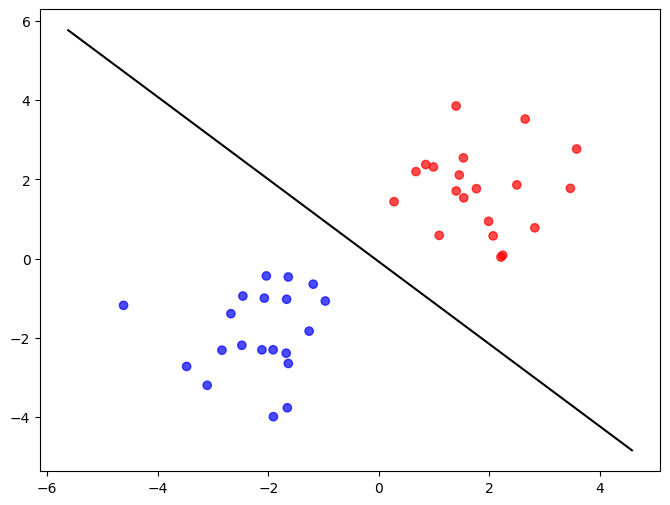

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

# ==========================================
# TASK 1: Equality Constrained Optimization
# ==========================================
print("\n--- TASK 1: Equality Constraints ---")

# Objective function: f(x, y) = (x-1)^2 + y^2
def objective_eq(x):
    return (x[0] - 1)**2 + x[1]**2

# Constraint: 2x + y = 1  → must be written as fun(x) = 0
def constraint_eq(x):
    return 2*x[0] + x[1] - 1

x0 = [0, 0]

cons_eq = {
    'type': 'eq',
    'fun': constraint_eq
}

#Do jacobian (derivative) and chk if it is a full rank ,
#and yes it is full rank and constraints are valid
#So we start solving system of equations in order to get optimal solution

sol_eq = minimize(objective_eq, x0, constraints=cons_eq)

print(f"Optimal Solution: {sol_eq.x}")

# ==========================================
# TASK 2: Inequality Constrained Optimization
# ==========================================
print("\n--- TASK 2: Inequality Constraints ---")

# Objective function
# We want to MAXIMIZE f(x, y) = x^2 + xy + y^2
# scipy minimizes → minimize -f
def objective_ineq(x):
    return -(x[0]**2 + x[0]*x[1] + x[1]**2)

# Constraint: x^2 + y^2 <= 1
# scipy requires ineq constraints as g(x) >= 0
# So: 1 - (x^2 + y^2) >= 0
def constraint_ineq(x):
    return 1 - (x[0]**2 + x[1]**2)

# Initial guess
x0 = [0.5, 0.5]

# Define inequality constraint
cons_ineq = {
    'type': 'ineq',
    'fun': constraint_ineq
}

# Run the minimization
sol_ineq = minimize(objective_ineq, x0, constraints=cons_ineq)

# Print solution
print(f"Optimal Solution: {sol_ineq.x}")

# ==========================================
# TASK 3: SVM Dual Implementation
# ==========================================
print("\n--- TASK 3: SVM Dual Formulation ---")

# ------------------------------
# Data Generation (Do not modify)
# ------------------------------
np.random.seed(42)
X1 = np.random.randn(20, 2) + [2, 2]
y1 = np.ones(20)
X2 = np.random.randn(20, 2) + [-2, -2]
y2 = -np.ones(20)

X = np.vstack((X1, X2))
y = np.hstack((y1, y2))

# --------------------------------
# 3.1 Dual Objective Function
# --------------------------------
def svm_dual_objective(lambdas, X, y):
    """
    Dual objective (to minimize):
    -( sum(lambda_i) - 0.5 * sum_i sum_j lambda_i lambda_j y_i y_j (x_i · x_j) )
    """

    # First term
    term1 = np.sum(lambdas)

    # Kernel matrix (linear kernel)
    K = np.dot(X, X.T)

    term2 = (lambdas *y).T @ np.dot(X,X.T) @ (lambdas *y)
    return -(term1 - 0.5 * term2)

# --------------------------------
# 3.2 Equality Constraint
# --------------------------------
def constraint_svm_bias(lambdas, y):
    # Sum(lambda_i * y_i) = 0
    return np.dot(lambdas, y)

# --------------------------------
# 3.3 Solve the Optimization
# --------------------------------
n_samples = len(y)
initial_lambdas = np.zeros(n_samples)

# Bounds: lambda_i >= 0
bounds = [(0, None) for _ in range(n_samples)]

# Equality constraint
constraints = ({
    'type': 'eq',
    'fun': constraint_svm_bias,
    'args': (y,)
})

solution = minimize(
    svm_dual_objective,
    initial_lambdas,
    args=(X, y),
    bounds=bounds,
    constraints=constraints
)

optimal_lambdas = solution.x

# --------------------------------
# 3.4 Recover w and b
# --------------------------------
# Support vectors
sv_indices = optimal_lambdas > 1e-5
x_optimal = X[sv_indices]
y_optimal = y[sv_indices]
lambdas_optimal = optimal_lambdas[sv_indices]

w = np.dot(lambdas_optimal* y_optimal , x_optimal)
# Compute b (average over support vectors)
b = np.mean(y[sv_indices] - np.dot(X[sv_indices], w))

# 3.5 Visualization (Uncomment when variables w and b are ready)
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr', alpha=0.7)
# Plot Decision Boundary
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
x_plot = np.linspace(x_min, x_max, 100)
# Derived from w[0]x + w[1]y + b = 0
y_plot = -(w[0] * x_plot + b) / w[1]
plt.plot(x_plot, y_plot, 'k-')
plt.show()
